# Notebook 13 — Hirsch-Calibrated Concept Scoring

The composite_score measures *general cultural salience* (Jeopardy frequency,
Wikipedia pageviews, crossword frequency, etc.) but **not** specifically
*cultural literacy* in Hirsch's sense.

**Problem:** US states (Tennessee, Alabama) score ~90 on composite because they
appear constantly in Jeopardy/crosswords — but they're not what Hirsch means by
cultural literacy. Meanwhile, concepts like 'Battle of Gettysburg' or
'manifest destiny' are central to Hirsch but may score lower.

**Solution:** Train a logistic regression on the 6 source-level percentile
scores + entity_type to predict **P(in_hirsch)**. This gives a
*data-driven cultural literacy score* calibrated exactly to Hirsch's definition.

**Features:**
- `pctile_jeopardy`, `pctile_wiki`, `pctile_xw` — quiz/reference salience
- `pctile_proverb`, `pctile_notable`, `pctile_geo` — domain signals
- `n_signals` — how many sources mention this concept
- `entity_type` (one-hot) — PERSON, GPE, CONCEPT, EVENT, NORP, LOC, ...

**Output:**
- `hirsch_prob` per concept (0-1)
- `data/hirsch_calibrated_concepts.csv` — composite + hirsch_prob
- Updated `data/work_concept_yield.csv` scored by hirsch_prob

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

DATA_DIR = Path('../data')
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data & Build `in_hirsch` Labels

In [2]:
# Load composite dataset
df = pd.read_csv(
    DATA_DIR / 'cultural_salience_composite_v2.csv',
    low_memory=False
)
print(f'Composite: {len(df):,} concepts')

# Load Hirsch terms and normalize
hirsch = pd.read_csv(DATA_DIR / 'hirsch_cultural_literacy_terms.csv')

def norm_term(s):
    return re.sub(r'[^a-z0-9 ]', '', str(s).lower()).strip()

hirsch['norm'] = hirsch['term'].apply(norm_term)
hirsch_set = set(hirsch['norm'].dropna())
print(f'Hirsch terms: {len(hirsch):,} ({len(hirsch_set):,} unique norms)')

# Build in_hirsch flag: match concept OR display_name against Hirsch norms
dn_norm = df['display_name'].apply(norm_term)
df['in_hirsch'] = (
    df['concept'].isin(hirsch_set) | dn_norm.isin(hirsch_set)
).astype(int)

print(f'\nin_hirsch positives: {df["in_hirsch"].sum():,} ({100*df["in_hirsch"].mean():.2f}%)')
print('\nBy entity type (Hirsch hit rate):')
et_stats = df.groupby('entity_type').agg(
    n=('concept','count'),
    n_hirsch=('in_hirsch','sum'),
    hirsch_rate=('in_hirsch','mean')
).sort_values('hirsch_rate', ascending=False)
print(et_stats.to_string(float_format='{:.3f}'.format))

Composite: 209,681 concepts
Hirsch terms: 6,953 (6,763 unique norms)



in_hirsch positives: 5,035 (2.40%)

By entity type (Hirsch hit rate):
                   n  n_hirsch  hirsch_rate
entity_type                                
NORP            2103       216        0.103
LAW               83         8        0.096
LANGUAGE          74         7        0.095
EVENT           1217        96        0.079
CONCEPT        19814      1465        0.074
GPE             9463       624        0.066
FAC              418        17        0.041
WORK_OF_ART    10523       386        0.037
PRODUCT          632        22        0.035
UNKNOWN        36145       889        0.025
ORG            13981       323        0.023
LOC             6482       139        0.021
PERSON         33269       534        0.016
PROVERB_IDIOM   9600       147        0.015
QUOTATION      65877       162        0.002


## 2. Feature Engineering

In [3]:
PCTILE_COLS = ['pctile_jeopardy', 'pctile_wiki', 'pctile_xw',
               'pctile_proverb', 'pctile_notable', 'pctile_geo']

# One-hot encode entity_type
et_dummies = pd.get_dummies(df['entity_type'], prefix='et')

# Feature matrix
X_df = pd.concat([
    df[PCTILE_COLS].fillna(0),
    df[['n_signals']],
    et_dummies,
], axis=1)

y = df['in_hirsch'].values
X = X_df.values

print(f'Feature matrix: {X.shape}')
print('Features:', list(X_df.columns))
print(f'\nClass balance: {y.sum():,} positive / {len(y)-y.sum():,} negative')
print(f'Positive rate: {100*y.mean():.2f}%')

Feature matrix: (209681, 22)
Features: ['pctile_jeopardy', 'pctile_wiki', 'pctile_xw', 'pctile_proverb', 'pctile_notable', 'pctile_geo', 'n_signals', 'et_CONCEPT', 'et_EVENT', 'et_FAC', 'et_GPE', 'et_LANGUAGE', 'et_LAW', 'et_LOC', 'et_NORP', 'et_ORG', 'et_PERSON', 'et_PRODUCT', 'et_PROVERB_IDIOM', 'et_QUOTATION', 'et_UNKNOWN', 'et_WORK_OF_ART']

Class balance: 5,035 positive / 204,646 negative
Positive rate: 2.40%


## 3. Model Training & Cross-Validation

In [4]:
# Logistic regression with class_weight='balanced' to handle 2.4% positive rate
# C=1.0 default regularization; scale features first
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        class_weight='balanced',
        max_iter=500,
        C=1.0,
        solver='lbfgs',
        random_state=42
    ))
])

print('Running 5-fold cross-validation...')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

roc_scores = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
ap_scores  = cross_val_score(pipe, X, y, cv=cv, scoring='average_precision', n_jobs=-1)

print(f'\nCross-validation results (5-fold):')
print(f'  ROC-AUC          : {roc_scores.mean():.4f} ± {roc_scores.std():.4f}')
print(f'  Avg Precision    : {ap_scores.mean():.4f} ± {ap_scores.std():.4f}')
print(f'  (Baseline AP if always predict negative: {1-y.mean():.4f})')

Running 5-fold cross-validation...



Cross-validation results (5-fold):
  ROC-AUC          : 0.8575 ± 0.0066
  Avg Precision    : 0.1778 ± 0.0073
  (Baseline AP if always predict negative: 0.9760)


In [5]:
# Train on full dataset for final predictions
pipe.fit(X, y)
hirsch_prob = pipe.predict_proba(X)[:, 1]

df['hirsch_prob'] = hirsch_prob
print(f'hirsch_prob computed for {len(df):,} concepts')
print(f'Distribution:')
print(pd.Series(hirsch_prob).describe(percentiles=[.5,.75,.9,.95,.99]).to_string(float_format='{:.4f}'.format))

# Check correlation with composite_score
corr = df[['composite_score','hirsch_prob']].corr().iloc[0,1]
print(f'\nCorrelation with composite_score: {corr:.3f}')

hirsch_prob computed for 209,681 concepts
Distribution:
count   209681.0000
mean         0.3136
std          0.2565
min          0.0223
50%          0.2076
75%          0.4055
90%          0.7580
95%          0.8331
99%          0.9011
max          0.9904

Correlation with composite_score: 0.479


## 4. Feature Importances

Feature importances (logistic regression coefficients, sorted by |coef|):
         feature    coef  abs_coef
 pctile_jeopardy  1.1965    1.1965
  pctile_proverb  0.8451    0.8451
    et_QUOTATION -0.6565    0.6565
      et_UNKNOWN  0.2877    0.2877
      et_CONCEPT  0.2684    0.2684
          et_GPE  0.1862    0.1862
  pctile_notable -0.1536    0.1536
         et_NORP  0.1191    0.1191
          et_LOC  0.1152    0.1152
et_PROVERB_IDIOM  0.0884    0.0884
        et_EVENT  0.0730    0.0730
          et_ORG  0.0585    0.0585
  et_WORK_OF_ART  0.0521    0.0521
       pctile_xw  0.0518    0.0518
       n_signals  0.0431    0.0431
     pctile_wiki  0.0346    0.0346
          et_LAW  0.0329    0.0329
     et_LANGUAGE  0.0266    0.0266
      pctile_geo -0.0248    0.0248
      et_PRODUCT  0.0219    0.0219
       et_PERSON -0.0156    0.0156
          et_FAC  0.0105    0.0105


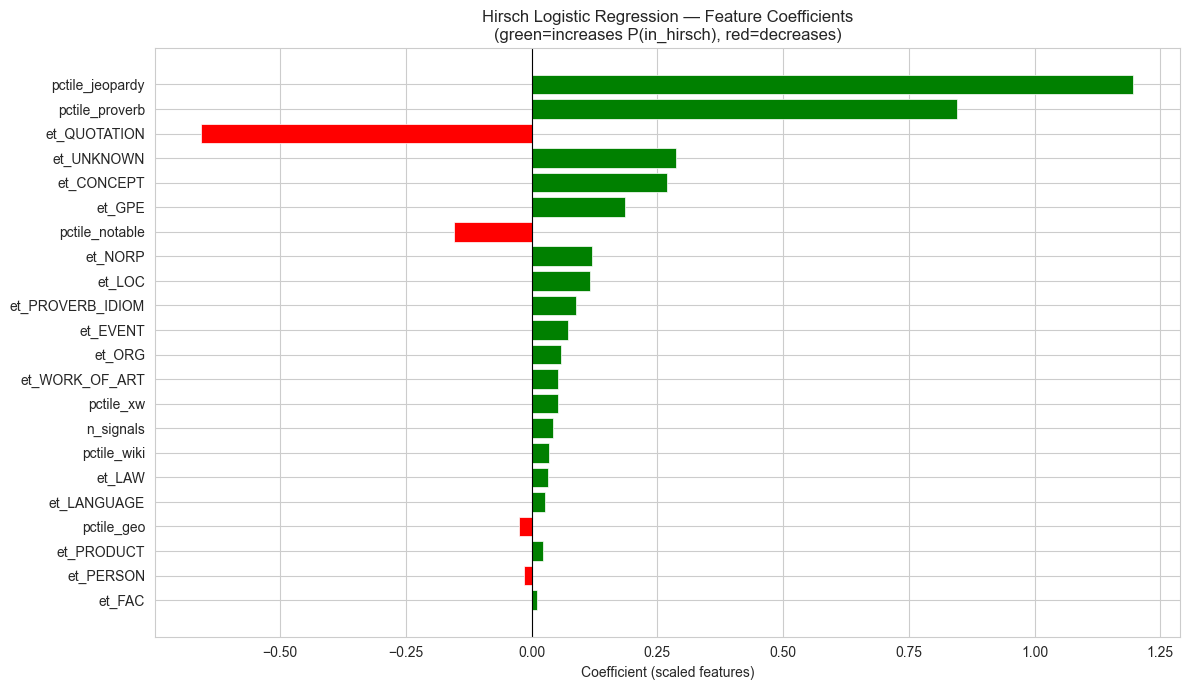

In [6]:
lr_model = pipe.named_steps['lr']
scaler   = pipe.named_steps['scaler']
feature_names = list(X_df.columns)

coefs = lr_model.coef_[0]
feat_imp = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs,
    'abs_coef': np.abs(coefs)
}).sort_values('abs_coef', ascending=False)

print('Feature importances (logistic regression coefficients, sorted by |coef|):')
print(feat_imp.to_string(index=False, float_format='{:.4f}'.format))

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['green' if c > 0 else 'red' for c in feat_imp.head(25)['coef']]
ax.barh(feat_imp.head(25)['feature'][::-1], feat_imp.head(25)['coef'][::-1],
        color=colors[::-1], edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Hirsch Logistic Regression — Feature Coefficients\n(green=increases P(in_hirsch), red=decreases)')
ax.set_xlabel('Coefficient (scaled features)')
plt.tight_layout()
plt.savefig(DATA_DIR / 'hirsch_feature_importances.png', dpi=150)
plt.show()

## 5. Validation — Spot Checks

In [7]:
def lookup(query):
    q = query.lower()
    mask = (
        df['concept'].str.lower().str.contains(q, na=False) |
        df['display_name'].str.lower().str.contains(q, na=False)
    )
    return df[mask][['display_name','entity_type','composite_score','hirsch_prob','in_hirsch','n_signals',
                      'pctile_jeopardy','pctile_wiki','pctile_xw','pctile_geo']].head(3)

# Known Hirsch terms that should have HIGH hirsch_prob
print('=== HIGH hirsch_prob expected (in Hirsch) ===')
for q in ['world war ii', 'manifest destiny', 'battle of gettysburg',
          'constitutional convention', 'french revolution', 'shakespeare']:
    r = lookup(q)
    if len(r):
        row = r.iloc[0]
        print(f'  {row["display_name"]:<35} hirsch_prob={row["hirsch_prob"]:.3f}  '
              f'in_hirsch={row["in_hirsch"]}  comp={row["composite_score"]:.1f}')

print()
# Geo-only concepts that should get LOWER hirsch_prob
print('=== LOW hirsch_prob expected (geo-heavy, not in Hirsch) ===')
for q in ['tennessee', 'alabama', 'nevada', 'minnesota', 'wyoming']:
    r = lookup(q)
    if len(r):
        row = r.iloc[0]
        print(f'  {row["display_name"]:<35} hirsch_prob={row["hirsch_prob"]:.3f}  '
              f'in_hirsch={row["in_hirsch"]}  comp={row["composite_score"]:.1f}')

print()
# Famous people — some in Hirsch, some not
print('=== PERSON spot checks ===')
for q in ['abraham lincoln', 'napoleon', 'sigmund freud', 'thomas jefferson', 'elvis presley']:
    r = lookup(q)
    if len(r):
        row = r.iloc[0]
        print(f'  {row["display_name"]:<35} hirsch_prob={row["hirsch_prob"]:.3f}  '
              f'in_hirsch={row["in_hirsch"]}  comp={row["composite_score"]:.1f}')

=== HIGH hirsch_prob expected (in Hirsch) ===
  World War II                        hirsch_prob=0.904  in_hirsch=1  comp=68.3


  Manifest Destiny                    hirsch_prob=0.853  in_hirsch=1  comp=75.6
  Battle of Gettysburg                hirsch_prob=0.666  in_hirsch=0  comp=62.5


  Constitutional Convention           hirsch_prob=0.867  in_hirsch=1  comp=94.9
  French Revolution                   hirsch_prob=0.935  in_hirsch=1  comp=74.8


  Shakespeare in Love                 hirsch_prob=0.772  in_hirsch=0  comp=95.5

=== LOW hirsch_prob expected (geo-heavy, not in Hirsch) ===
  Tennessee                           hirsch_prob=0.940  in_hirsch=1  comp=90.5


  Alabama                             hirsch_prob=0.909  in_hirsch=1  comp=96.3
  Nevada                              hirsch_prob=0.909  in_hirsch=1  comp=95.2


  Minnesota Vikings                   hirsch_prob=0.849  in_hirsch=0  comp=91.6
  Cheyenne, Wyoming                   hirsch_prob=0.823  in_hirsch=0  comp=86.6

=== PERSON spot checks ===


  Abraham Lincoln                     hirsch_prob=0.695  in_hirsch=0  comp=92.5
  Napoleon                            hirsch_prob=0.699  in_hirsch=0  comp=95.1


  Sigmund Freud                       hirsch_prob=0.555  in_hirsch=0  comp=79.9
  Thomas Jefferson                    hirsch_prob=0.696  in_hirsch=0  comp=93.2


  Elvis Presley                       hirsch_prob=0.572  in_hirsch=0  comp=86.9


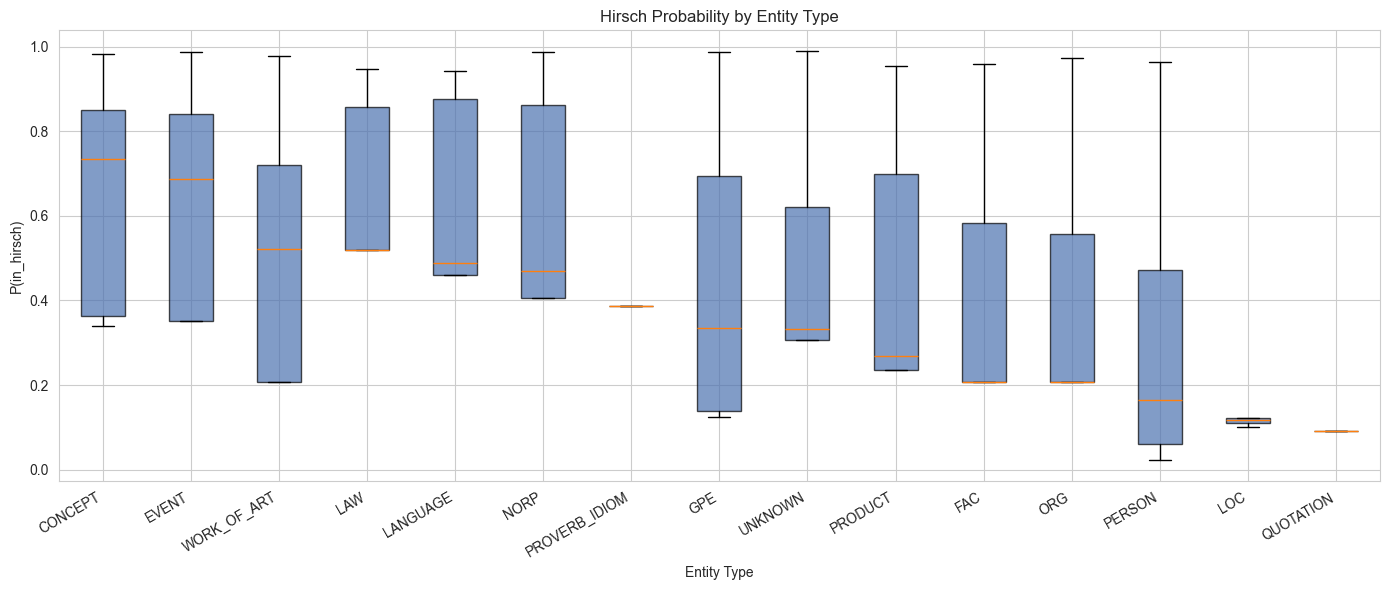

Mean P(in_hirsch) by entity type:
                mean  median  count
entity_type                        
LAW           0.6649  0.5189     83
CONCEPT       0.6468  0.7351  19814
LANGUAGE      0.6436  0.4875     74
NORP          0.6286  0.4699   2103
EVENT         0.6218  0.6866   1217
WORK_OF_ART   0.4883  0.5209  10523
PRODUCT       0.4450  0.2695    632
UNKNOWN       0.4378  0.3319  36145
GPE           0.4202  0.3360   9463
PROVERB_IDIOM 0.3863  0.3862   9600
FAC           0.3827  0.2070    418
ORG           0.3721  0.2069  13981
PERSON        0.2725  0.1651  33269
LOC           0.2154  0.1172   6482
QUOTATION     0.0911  0.0911  65877


In [8]:
# Distribution of hirsch_prob by entity_type — box plots
fig, ax = plt.subplots(figsize=(14, 6))
order = df.groupby('entity_type')['hirsch_prob'].median().sort_values(ascending=False).index
et_data = [df[df['entity_type']==et]['hirsch_prob'].values for et in order]
bp = ax.boxplot(et_data, labels=order, patch_artist=True, showfliers=False)
for patch in bp['boxes']:
    patch.set_facecolor('#4C72B0')
    patch.set_alpha(0.7)
ax.set_xlabel('Entity Type')
ax.set_ylabel('P(in_hirsch)')
ax.set_title('Hirsch Probability by Entity Type')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(DATA_DIR / 'hirsch_prob_by_entity_type.png', dpi=150)
plt.show()

# Mean hirsch_prob by entity type
print('Mean P(in_hirsch) by entity type:')
print(df.groupby('entity_type')['hirsch_prob'].agg(['mean','median','count'])
      .sort_values('mean', ascending=False)
      .to_string(float_format='{:.4f}'.format))

In [9]:
# Compare top concepts by composite_score vs hirsch_prob
print('TOP 30 by composite_score (general salience):')
top_comp = df.nlargest(30, 'composite_score')[[
    'display_name','entity_type','composite_score','hirsch_prob','in_hirsch'
]]
print(top_comp.to_string(index=False, float_format='{:.3f}'.format))

print('\nTOP 30 by hirsch_prob (cultural literacy calibrated):')
top_hirsch = df.nlargest(30, 'hirsch_prob')[[
    'display_name','entity_type','composite_score','hirsch_prob','in_hirsch'
]]
print(top_hirsch.to_string(index=False, float_format='{:.3f}'.format))

TOP 30 by composite_score (general salience):
                            display_name   entity_type  composite_score  hirsch_prob  in_hirsch
      neither a borrower nor a lender be PROVERB_IDIOM           99.996        0.784          1
                     many a time and oft PROVERB_IDIOM           99.996        0.784          0
hope springs eternal in the human breast PROVERB_IDIOM           99.996        0.784          0
                                   Q2831        PERSON           99.969        0.022          0
                                       3       CONCEPT           99.929        0.887          0
                                       4       CONCEPT           99.910        0.887          0
                                       2       CONCEPT           99.903        0.887          0
                                     tea       CONCEPT           99.897        0.912          0
                                    iron       CONCEPT           99.891        0.912      

## 6. Precision-Recall Analysis

Threshold sensitivity:
 threshold  precision  recall  n_predicted   tp     fp
     0.050      0.025   1.000       203157 5034 198123
     0.100      0.036   0.967       134217 4868 129349
     0.150      0.039   0.966       125987 4864 121123
     0.200      0.042   0.951       114321 4787 109534
     0.250      0.047   0.929       100592 4679  95913
     0.300      0.047   0.926        99478 4663  94815
     0.400      0.075   0.792        53085 3989  49096
     0.500      0.083   0.774        46729 3895  42834


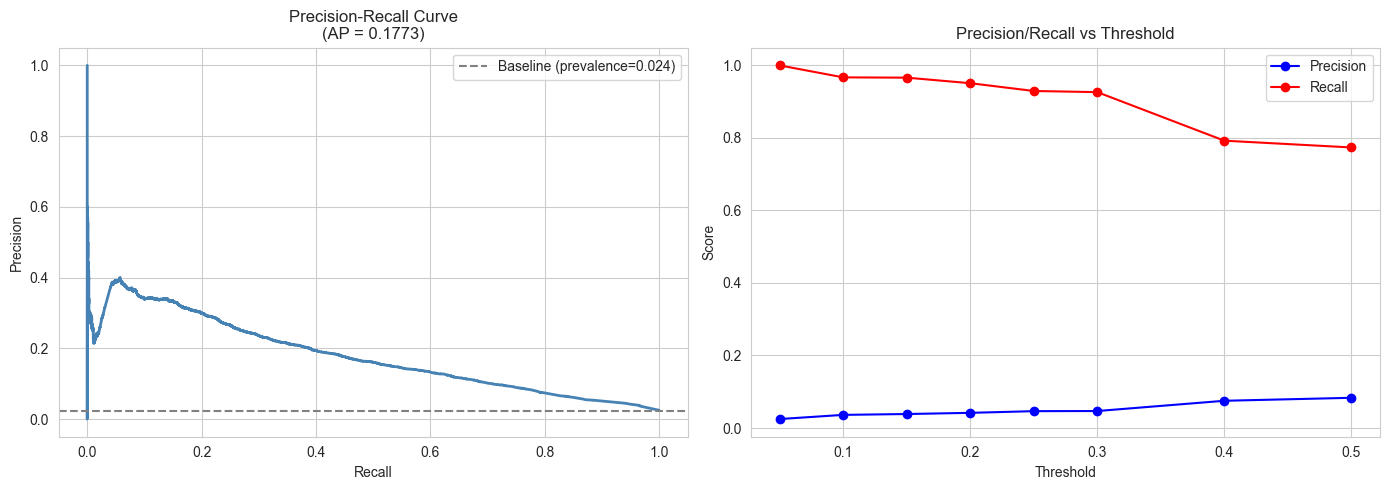

In [10]:
precision, recall, thresholds = precision_recall_curve(y, hirsch_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(recall, precision, color='steelblue', linewidth=2)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall Curve\n(AP = {average_precision_score(y, hirsch_prob):.4f})')
ax.axhline(y.mean(), color='gray', linestyle='--', label=f'Baseline (prevalence={y.mean():.3f})')
ax.legend()

# Threshold sensitivity table
ax = axes[1]
thresh_vals = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
rows_t = []
for t in thresh_vals:
    pred = (hirsch_prob >= t).astype(int)
    tp = ((pred==1) & (y==1)).sum()
    fp = ((pred==1) & (y==0)).sum()
    fn = ((pred==0) & (y==1)).sum()
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0
    rows_t.append({'threshold':t, 'precision':prec, 'recall':rec,
                   'n_predicted':pred.sum(), 'tp':tp, 'fp':fp})
thresh_df = pd.DataFrame(rows_t)
print('Threshold sensitivity:')
print(thresh_df.to_string(index=False, float_format='{:.3f}'.format))

ax.plot(thresh_df['threshold'], thresh_df['precision'], 'b-o', label='Precision')
ax.plot(thresh_df['threshold'], thresh_df['recall'], 'r-o', label='Recall')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision/Recall vs Threshold')
ax.legend()

plt.tight_layout()
plt.savefig(DATA_DIR / 'hirsch_precision_recall.png', dpi=150)
plt.show()

## 7. Re-Score Work Concept Yield

In [11]:
# Build lookup: concept_norm -> hirsch_prob
prob_lookup = dict(zip(df['concept'], df['hirsch_prob']))

# Load work_concept_tags
tags = pd.read_csv(DATA_DIR / 'work_concept_tags.csv')
print(f'Tags: {len(tags):,} rows')

# Map hirsch_prob onto matched tags
# matched_concept is already normalized concept from composite
tags['hirsch_prob'] = tags['matched_concept'].map(prob_lookup).fillna(0.0)

# Only score matched tags
matched = tags[tags['matched_concept'].notna()].copy()
print(f'Matched tags: {len(matched):,}')
print(f'Average hirsch_prob on matched tags: {matched["hirsch_prob"].mean():.4f}')

# New yield formula: sum(relevance * hirsch_prob) per work
# vs old: sum(relevance * matched_score * composite_score/100)
matched['hirsch_yield_contrib'] = matched['relevance'] * matched['hirsch_prob']

hirsch_yield = (
    matched.groupby('work_id')
    .agg(
        n_matched=('matched_concept', 'nunique'),
        hirsch_yield=('hirsch_yield_contrib', 'sum'),
        avg_hirsch_prob=('hirsch_prob', 'mean'),
    )
    .reset_index()
)

# Merge with existing work_concept_yield for comparison
old_yield = pd.read_csv(DATA_DIR / 'work_concept_yield.csv')
compare = hirsch_yield.merge(
    old_yield[['work_id','title','medium','year','importance_score','concept_yield']],
    on='work_id', how='left'
)

print(f'\nWorks with hirsch_yield: {len(compare):,}')

Tags: 20,903 rows
Matched tags: 9,263
Average hirsch_prob on matched tags: 0.7312

Works with hirsch_yield: 853


In [12]:
# Normalize both yields 0-100 for comparison
compare['yield_norm']  = 100 * compare['concept_yield']  / compare['concept_yield'].max()
compare['hyield_norm'] = 100 * compare['hirsch_yield']   / compare['hirsch_yield'].max()

# Combined score: 50% importance + 50% hirsch_yield
works_scored = pd.read_csv(DATA_DIR / 'works_scored.csv')
imp_max = works_scored['importance_score'].max()
compare['imp_norm'] = 100 * compare['importance_score'] / imp_max
compare['hirsch_combined'] = 0.5 * compare['imp_norm'] + 0.5 * compare['hyield_norm']
compare = compare.sort_values('hirsch_combined', ascending=False).reset_index(drop=True)

print('TOP 30 FILMS by Hirsch-calibrated combined score:')
top_films = compare[compare['medium']=='film'].head(30)
print(top_films[['title','year','importance_score','hirsch_yield','avg_hirsch_prob','hirsch_combined']]
      .to_string(index=False, float_format='{:.3f}'.format))

print('\nTOP 30 NOVELS by Hirsch-calibrated combined score:')
top_novels = compare[compare['medium']=='novel'].head(30)
print(top_novels[['title','year','importance_score','hirsch_yield','avg_hirsch_prob','hirsch_combined']]
      .to_string(index=False, float_format='{:.3f}'.format))

TOP 30 FILMS by Hirsch-calibrated combined score:
                                   title   year  importance_score  hirsch_yield  avg_hirsch_prob  hirsch_combined
                                   Elvis 2022.0            86.000        50.581            0.792           93.000
                             Raging Bull 1980.0            84.733        41.947            0.741           83.832
                             The Martian 2015.0            98.667        30.150            0.739           79.137
                        Zero Dark Thirty 2012.0            86.000        35.548            0.792           78.140
Harry Potter and the Philosopher's Stone 2001.0            85.081        32.721            0.755           74.886
                                 Lincoln 2012.0            96.000        26.267            0.727           73.966
                       Kingdom of Heaven 2005.0            97.333        24.639            0.720           73.023
                The Shawshank Redempti

In [13]:
# Rank shift analysis: how much do rankings change from old to new scoring?
old_rank = compare.sort_values('concept_yield', ascending=False).reset_index(drop=True)
old_rank['old_rank'] = old_rank.index + 1

new_rank = compare.sort_values('hirsch_combined', ascending=False).reset_index(drop=True)
new_rank['new_rank'] = new_rank.index + 1

ranks = old_rank[['work_id','title','medium','old_rank']].merge(
    new_rank[['work_id','new_rank','hirsch_combined','avg_hirsch_prob']],
    on='work_id'
)
ranks['rank_shift'] = ranks['old_rank'] - ranks['new_rank']  # positive = moved UP

print('BIGGEST MOVERS UP (gained most from Hirsch calibration):')
print(ranks.nlargest(20,'rank_shift')[['title','medium','old_rank','new_rank','rank_shift','avg_hirsch_prob']]
      .to_string(index=False))

print('\nBIGGEST MOVERS DOWN (penalized by Hirsch calibration):')
print(ranks.nsmallest(20,'rank_shift')[['title','medium','old_rank','new_rank','rank_shift','avg_hirsch_prob']]
      .to_string(index=False))

BIGGEST MOVERS UP (gained most from Hirsch calibration):
                                                    title medium  old_rank  new_rank  rank_shift  avg_hirsch_prob
                                  The Edge of Sadness[an]  novel       827       292         535         0.902292
                                  The Optimist's Daughter  novel       761       227         534         0.856863
                                   Advise and Consent[al]  novel       799       265         534         0.880384
           The Collected Stories of Katherine Anne Porter  novel       784       257         527         0.810743
                                           Hell of a Book  novel       814       290         524         0.912649
                 A Death in the Family[aj] (posthumously)  novel       845       322         523         0.609246
                                                  Saville  novel       830       308         522         0.690772
                        The Con

## 8. Export

In [14]:
# 1. Save hirsch_prob appended to composite
out_concepts = df[['concept','display_name','entity_type','composite_score',
                    'n_signals','pctile_jeopardy','pctile_wiki','pctile_xw',
                    'pctile_proverb','pctile_notable','pctile_geo',
                    'in_hirsch','hirsch_prob']].copy()
out_path = DATA_DIR / 'hirsch_calibrated_concepts.csv'
out_concepts.to_csv(out_path, index=False)
print(f'Saved {len(out_concepts):,} concepts -> {out_path}')

# 2. Save updated work scores with hirsch_combined
works_hirsch = compare.sort_values('hirsch_combined', ascending=False)
hirsch_path = DATA_DIR / 'works_hirsch_scored.csv'
works_hirsch.to_csv(hirsch_path, index=False)
print(f'Saved {len(works_hirsch):,} works -> {hirsch_path}')

print('\n=== SUMMARY ===')
print(f'Model: Logistic Regression (balanced classes, C=1.0)')
print(f'Features: 6 percentile scores + n_signals + entity_type one-hot')
print(f'Training size: {len(df):,} concepts ({df["in_hirsch"].sum():,} Hirsch positives)')
print(f'ROC-AUC (5-fold CV): {roc_scores.mean():.4f}')
print(f'Avg Precision (5-fold CV): {ap_scores.mean():.4f}')
print()
print(f'#1 Film (old scoring): {compare.sort_values("concept_yield",ascending=False).iloc[0]["title"]}')
print(f'#1 Film (new Hirsch): {compare[compare["medium"]=="film"].iloc[0]["title"]}')

Saved 209,681 concepts -> ..\data\hirsch_calibrated_concepts.csv
Saved 853 works -> ..\data\works_hirsch_scored.csv

=== SUMMARY ===
Model: Logistic Regression (balanced classes, C=1.0)
Features: 6 percentile scores + n_signals + entity_type one-hot
Training size: 209,681 concepts (5,035 Hirsch positives)
ROC-AUC (5-fold CV): 0.8575
Avg Precision (5-fold CV): 0.1778

#1 Film (old scoring): Elvis
#1 Film (new Hirsch): Elvis
